In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../data/Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
dashboard_df = df[
    [
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "Contract",
        "PaymentMethod",
        "InternetService",
        "Churn"
    ]
]

In [5]:
dashboard_df.head()

,tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,InternetService,Churn
0,1,29.85,29.85,Month-to-month,Electronic check,DSL,No
1,34,56.95,1889.5,One year,Mailed check,DSL,No
2,2,53.85,108.15,Month-to-month,Mailed check,DSL,Yes
3,45,42.30,1840.75,One year,Bank transfer (automatic),DSL,No
4,2,70.70,151.65,Month-to-month,Electronic check,Fiber optic,Yes


In [6]:
dashboard_df.isnull().sum()


tenure             0
MonthlyCharges     0
TotalCharges       0
Contract           0
PaymentMethod      0
InternetService    0
Churn              0
dtype: int64

In [7]:
dashboard_df.to_csv("../data/dashboard_data.csv", index=False)

In [8]:
import os

os.listdir("../data")

['dashboard_data.csv',
 'Telco-Customer-Churn-Clean.csv',
 'Telco-Customer-Churn.csv']

## 1. Customer Churn Distribution

This chart shows the number of customers who stayed and those who churned.

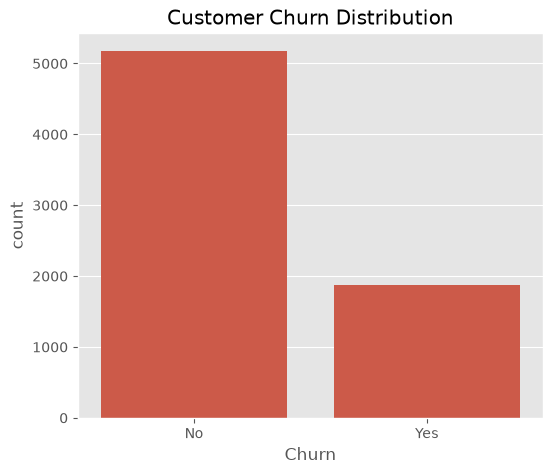

In [9]:
plt.figure(figsize=(6,5))

sns.countplot(x="Churn",data=dashboard_df)

plt.title("Customer Churn Distribution")

plt.show()

## 2. Contract Type Distribution

This chart shows how customers are distributed across different contract types.

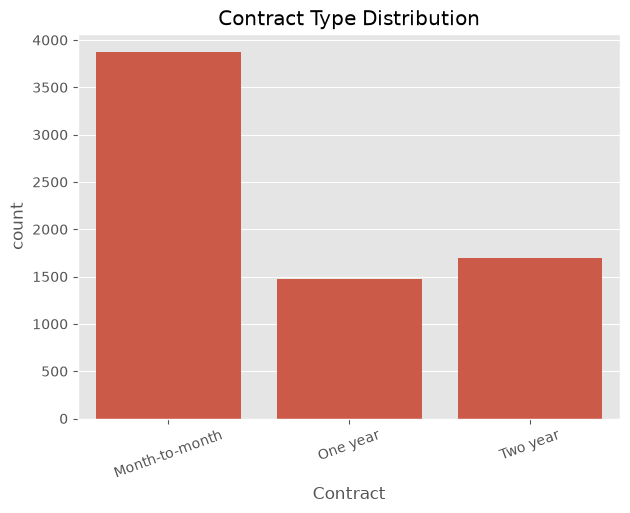

In [10]:
plt.figure(figsize=(7,5))

sns.countplot(x="Contract",data=dashboard_df)

plt.title("Contract Type Distribution")

plt.xticks(rotation=20)

plt.show()

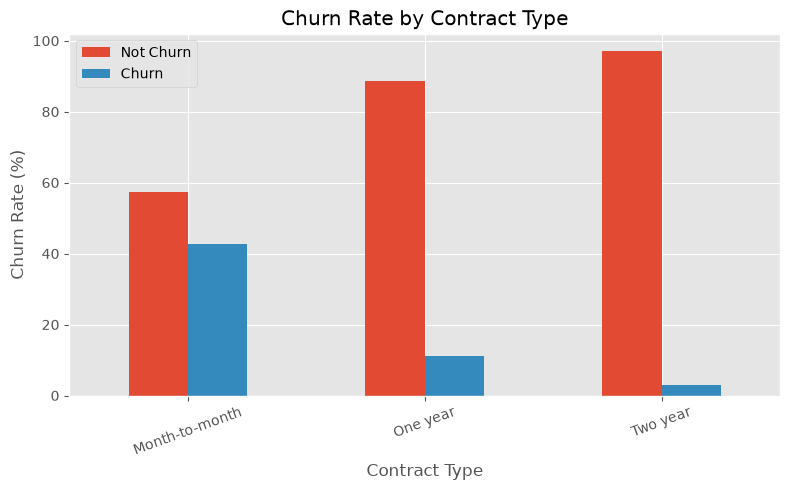

In [14]:
# Churn Rate by Contract Type

contract_churn = pd.crosstab(
    dashboard_df["Contract"],
    dashboard_df["Churn"],
    normalize="index"
) * 100

contract_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
plt.legend(["Not Churn", "Churn"])
plt.tight_layout()
plt.show()

## 3. Monthly Charges Distribution

This histogram shows how monthly charges are distributed among customers.

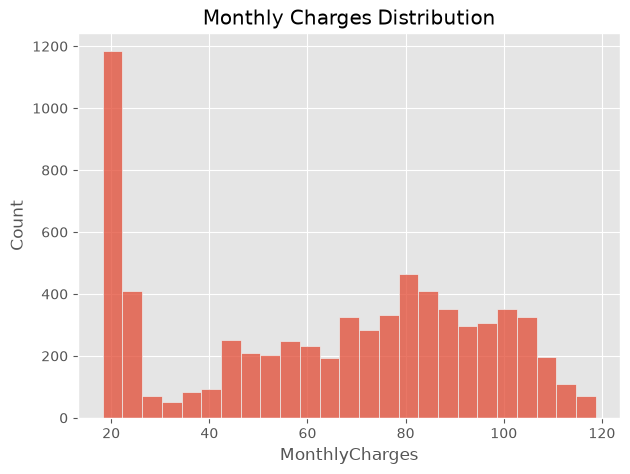

In [11]:
plt.figure(figsize=(7,5))

sns.histplot(dashboard_df["MonthlyCharges"],bins=25)

plt.title("Monthly Charges Distribution")

plt.show()

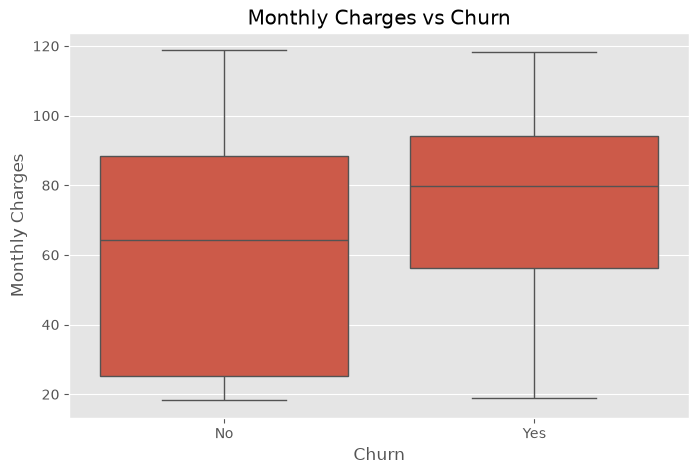

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=dashboard_df
)

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

## 4. Customer Tenure Distribution

This chart shows how long customers have stayed with the company.

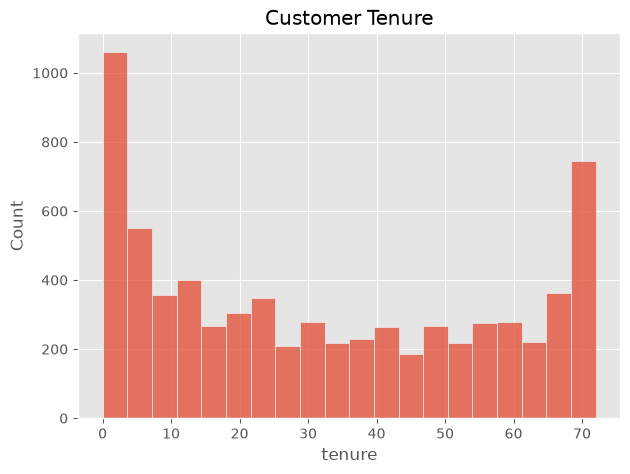

In [12]:
plt.figure(figsize=(7,5))

sns.histplot(dashboard_df["tenure"],bins=20)

plt.title("Customer Tenure")

plt.show()

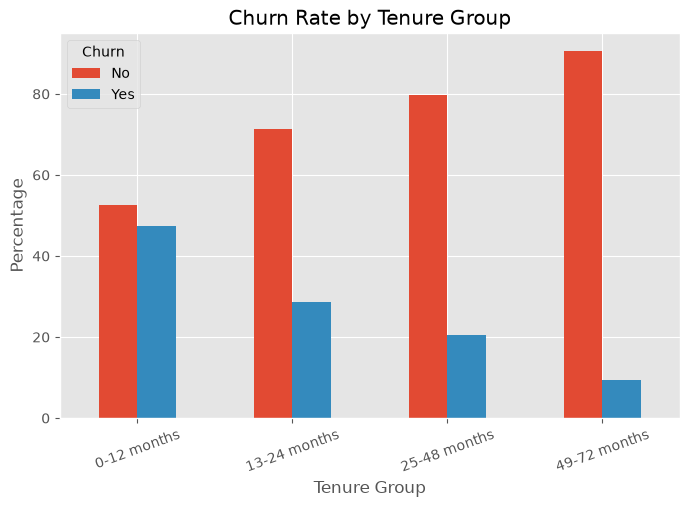

In [15]:
dashboard_df["TenureGroup"] = pd.cut(
    dashboard_df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12 months", "13-24 months", "25-48 months", "49-72 months"],
    include_lowest=True
)

tenure_churn = pd.crosstab(
    dashboard_df["TenureGroup"],
    dashboard_df["Churn"],
    normalize="index"
) * 100

tenure_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Percentage")
plt.xticks(rotation=20)
plt.legend(title="Churn")
plt.show()

## 5. Correlation Heatmap

This heatmap shows the relationship between the numerical features in the dataset.

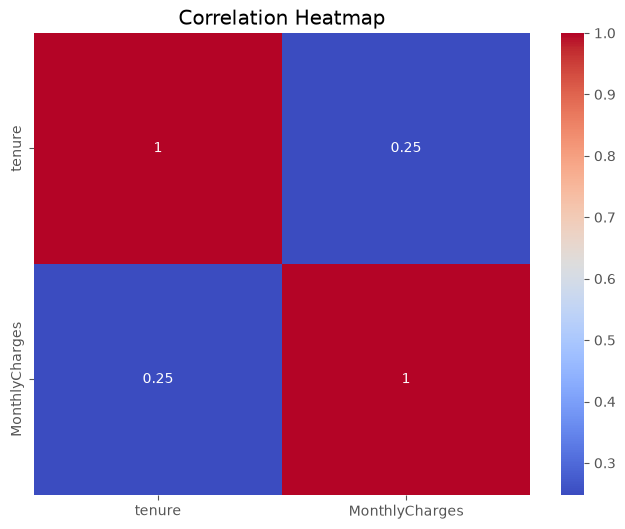

In [13]:
numeric = dashboard_df.select_dtypes(include=["number"])

plt.figure(figsize=(8,6))

sns.heatmap(numeric.corr(),annot=True,cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

# Day 22

- Dashboard finalized
- Charts exported
- Feature importance visualization added
- Ready for presentation

# Day 24

- Dashboard dataset prepared
- Dashboard charts verified
- API testing completed

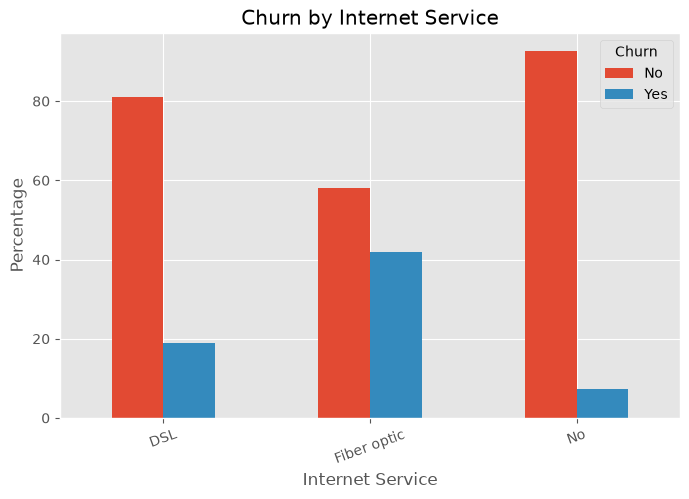

In [17]:
internet_churn = pd.crosstab(
    dashboard_df["InternetService"],
    dashboard_df["Churn"],
    normalize="index"
) * 100

internet_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Percentage")
plt.xticks(rotation=20)
plt.legend(title="Churn")
plt.show()